First five rows of dataset:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

K-Means Silhouette Score: 0.4787241921049546
Hierarchical Clustering Silhouette Score: 0.44553956399200406


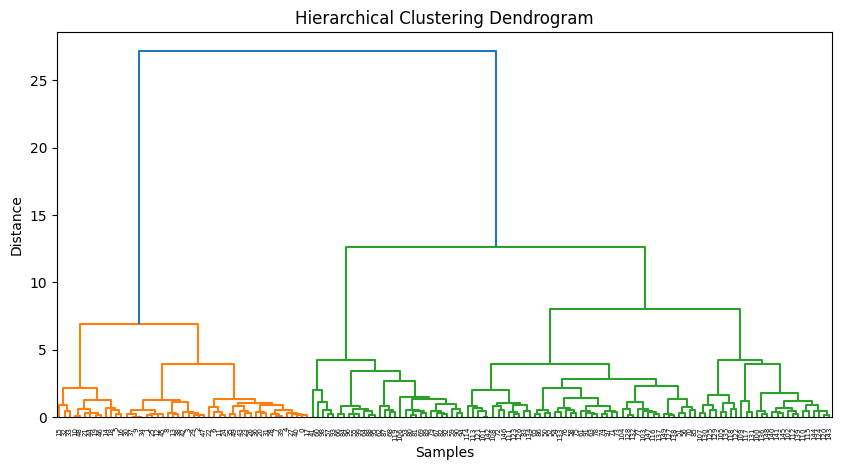

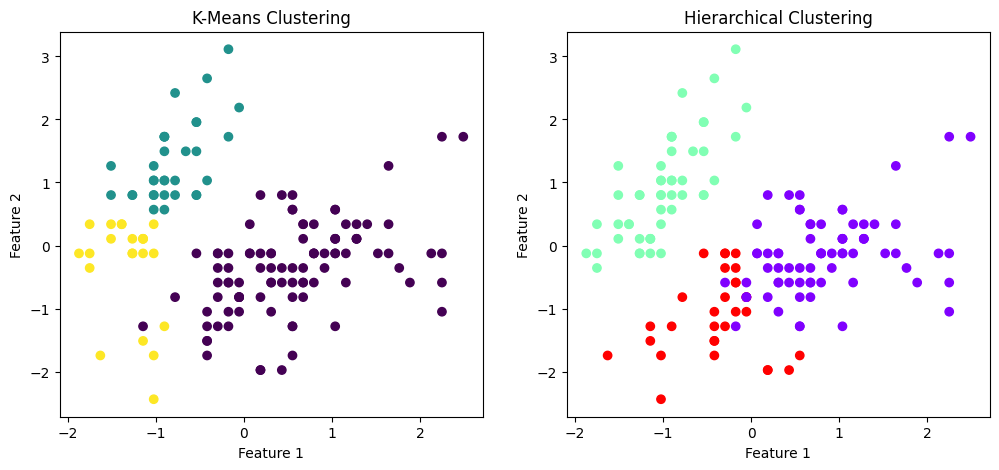

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the IRIS Dataset, assuming it has a header row (e.g., Id,SepalLengthCm,...)
data = pd.read_csv("/content/Iris.csv")

# Drop the 'Id' column if it exists, as it's typically not a feature for clustering
if 'Id' in data.columns:
    data = data.drop("Id", axis=1)

# Rename columns to a consistent format (lowercase, underscore separated)
data.rename(columns={
    "SepalLengthCm": "sepal_length",
    "SepalWidthCm": "sepal_width",
    "PetalLengthCm": "petal_length",
    "PetalWidthCm": "petal_width",
    "Species": "species"
}, inplace=True)

# Separate features and target
df = data.drop("species", axis=1)
print("First five rows of dataset:")
print(df.head())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto') # Added n_init to suppress warning
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("\nK-Means Silhouette Score:", kmeans_silhouette)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hierarchical_labels

# Evaluate Hierarchical clustering
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)

# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Visualization of Clusters
plt.figure(figsize=(12,5))
# KMeans Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
# Hierarchical Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hierarchical_labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()